In [1]:
# Cell 1 - Install required packages (run once)
!pip install -q imbalanced-learn statsmodels
# Cell 2 - Imports & configurations
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import statsmodels.api as sm
from scipy import stats

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Filenames (must match exactly)
JPM_PATH = "JPM.csv"
BAC_PATH = "BAC.csv"
WFC_PATH = "WFC.csv"
VIX_PATH = "VIX.csv"
SPX_PATH = "SPX500.csv"
FED_PATH = "FED_RATE.csv"

print("Ready. Working dir:", os.getcwd())


Ready. Working dir: /content


In [4]:
# Cell 3 (REPLACEMENT) - Robust loader for the six files (works with different Date column names)
import pandas as pd

def load_csv_normalize_date(path):
    print(f"\nLoading {path} ...")
    df = pd.read_csv(path, dtype=str)  # read as strings first for diagnostics
    cols = list(df.columns)
    print("  Columns found:", cols[:10], "..." if len(cols)>10 else "")

    # try to find a date-like column name (case-insensitive)
    date_col = None
    for c in cols:
        if 'date' == c.strip().lower() or 'time' == c.strip().lower() or 'timestamp' == c.strip().lower():
            date_col = c
            break
    # also accept columns containing 'date' or 'time'
    if date_col is None:
        for c in cols:
            if 'date' in c.strip().lower() or 'time' in c.strip().lower():
                date_col = c
                break

    # if still not found, try first column
    if date_col is None and len(cols) > 0:
        print("  No obvious date column name found — will try first column:", cols[0])
        date_col = cols[0]

    # parse the column as datetime
    try:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=False)
    except Exception as e:
        print("  Error parsing dates from column", date_col, ":", e)
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=False)

    # If parsing failed (all NaT), try alternative parse strategies
    if df[date_col].isna().all():
        print("  Warning: parsed date column", date_col, "is all NaT. Trying to coerce numeric timestamps or alternative formats.")
        # try common formats
        tried = False
        for fmt in ("%m/%d/%Y %H:%M", "%m/%d/%Y", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"):
            try:
                df[date_col] = pd.to_datetime(df[date_col], format=fmt, errors='coerce')
                if not df[date_col].isna().all():
                    tried = True
                    print("   Success with format", fmt)
                    break
            except:
                pass
        if not tried:
            # try parse by replacing dots/comma
            df[date_col] = pd.to_datetime(df[date_col].str.replace('.', '/').str.replace('-', '/'), errors='coerce')

    # normalize to date only (drop time component)
    df['Date_normalized'] = df[date_col].dt.normalize()
    # if Date_normalized is all NaT -> error
    if df['Date_normalized'].isna().all():
        raise KeyError(f"Could not parse any valid dates from file {path}. Please check the CSV header and date formats.")

    # Now drop the original raw column (optional) and set index
    df = df.drop(columns=[date_col]) if date_col in df.columns else df
    df = df.set_index('Date_normalized').sort_index()

    # convert numeric-looking columns to numeric (coerce)
    for c in df.columns:
        # skip columns that were non-numeric entirely (like string columns)
        try:
            df[c] = pd.to_numeric(df[c], errors='coerce')
        except:
            pass

    print(f"  Loaded {path}: rows={len(df)}, index from {df.index.min().date()} to {df.index.max().date()}")
    return df

# Use the robust loader for all six files
jpm = load_csv_normalize_date(JPM_PATH)
bac = load_csv_normalize_date(BAC_PATH)
wfc = load_csv_normalize_date(WFC_PATH)
vix = load_csv_normalize_date(VIX_PATH)
spx = load_csv_normalize_date(SPX_PATH)
fed = load_csv_normalize_date(FED_PATH)

# Quick sanity prints
print("\nSanity checks (first 3 rows each):")
print("JPM:")
display(jpm.head(3))
print("VIX:")
display(vix.head(3))
print("SPX:")
display(spx.head(3))
print("FED (first columns):")
display(fed.head(3))



Loading JPM.csv ...
  Columns found: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume'] 
  Loaded JPM.csv: rows=1977, index from 2018-01-02 to 2025-11-11

Loading BAC.csv ...
  Columns found: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume'] 
  Loaded BAC.csv: rows=1977, index from 2018-01-02 to 2025-11-11

Loading WFC.csv ...
  Columns found: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume'] 
  Loaded WFC.csv: rows=1974, index from 2018-01-02 to 2025-11-11

Loading VIX.csv ...
  Columns found: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume'] 
  Loaded VIX.csv: rows=1977, index from 2018-01-02 to 2025-11-11

Loading SPX500.csv ...
  Columns found: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume'] 
  Loaded SPX500.csv: rows=1977, index from 2018-01-02 to 2025-11-11

Loading FED_RATE.csv ...
  Columns found: ['Date', 'EFFR'] 
  Loaded FED_RATE.csv: rows=2049, index from 2018-01-02 to 2025-11-07

Sanity checks (first 3 rows each):
JPM:


,Open,High,Low,Close,Volume
Date_normalized,,,,,
2018-01-02,107.63,108.02,106.81,107.95,13578835
2018-01-03,107.86,108.49,107.48,108.06,11901037
2018-01-04,108.36,110.03,108.20,109.04,12953656


VIX:


,Close,High,Low,Open,Volume
Date_normalized,,,,,
2018-01-02,9.77,11.07,9.52,10.95,0
2018-01-03,9.15,9.65,8.94,9.56,0
2018-01-04,9.22,9.31,8.92,9.01,0


SPX:


,Close,High,Low,Open,Volume
Date_normalized,,,,,
2018-01-02,2695.810059,2695.889893,2682.360107,2683.729980,3397430000
2018-01-03,2713.060059,2714.370117,2697.770020,2697.850098,3544030000
2018-01-04,2723.989990,2729.290039,2719.070068,2719.310059,3697340000


FED (first columns):


,EFFR
Date_normalized,
2018-01-02,1.42
2018-01-03,1.42
2018-01-04,1.42


In [5]:
# Cell 4 - Merge into single DataFrame
start_date = pd.to_datetime("2018-01-01")
end_date = pd.to_datetime("2025-11-11")

# union of all dates
idx = jpm.index.union(bac.index).union(wfc.index).union(vix.index).union(spx.index).union(fed.index)
df = pd.DataFrame(index=idx.sort_values())

# Stock price columns (rename Close->TICKER_Close, Volume->TICKER_Volume)
def join_stock(df, stock_df, ticker):
    cols = []
    if 'Close' in stock_df.columns:
        df = df.join(stock_df[['Close']].rename(columns={'Close':f'{ticker}_Close'}), how='left')
    if 'Volume' in stock_df.columns:
        df = df.join(stock_df[['Volume']].rename(columns={'Volume':f'{ticker}_Volume'}), how='left')
    return df

df = join_stock(df, jpm, 'JPM')
df = join_stock(df, bac, 'BAC')
df = join_stock(df, wfc, 'WFC')

# Market indicators
if 'Close' in vix.columns:
    df = df.join(vix[['Close']].rename(columns={'Close':'VIX'}), how='left')
else:
    df = df.join(vix.iloc[:,0].rename('VIX'), how='left')

if 'Close' in spx.columns:
    df = df.join(spx[['Close']].rename(columns={'Close':'SPX500'}), how='left')
else:
    df = df.join(spx.iloc[:,0].rename('SPX500'), how='left')

# FED EFFR
if 'EFFR' in fed.columns:
    df = df.join(fed[['EFFR']], how='left')
else:
    df = df.join(fed.iloc[:,0].rename('EFFR'), how='left')

# Restrict period and forward-fill market series
df = df.loc[(df.index >= start_date) & (df.index <= end_date)].sort_index()
df[['VIX','SPX500','EFFR']] = df[['VIX','SPX500','EFFR']].ffill()

print("Merged df shape:", df.shape)
display(df.head(5))


Merged df shape: (2051, 9)


,JPM_Close,JPM_Volume,BAC_Close,BAC_Volume,WFC_Close,WFC_Volume,VIX,SPX500,EFFR
Date_normalized,,,,,,,,,
2018-01-02,107.95,13578835.0,29.90,57121603.0,61.09,13819293.0,9.77,2695.810059,1.42
2018-01-03,108.06,11901037.0,29.80,57865727.0,61.56,14203721.0,9.15,2713.060059,1.42
2018-01-04,109.04,12953656.0,30.19,76512451.0,62.33,18740512.0,9.22,2723.989990,1.42
2018-01-05,108.34,14154974.0,30.33,56445186.0,62.75,14217871.0,9.22,2743.149902,1.42
2018-01-08,108.50,12466512.0,30.12,42914839.0,62.04,15569369.0,9.52,2747.709961,1.42


In [6]:
# Cell 5 - Feature engineering helpers and application
def log_return(series):
    return np.log(series / series.shift(1))

def rolling_vol(series, w=10):
    return series.pct_change().rolling(w).std()

def ma(series, w):
    return series.rolling(w).mean()

def rsi(series, period=14):
    delta = series.diff()
    up = delta.clip(lower=0)
    down = -delta.clip(upper=0)
    ma_up = up.rolling(period).mean()
    ma_down = down.rolling(period).mean()
    rs = ma_up / ma_down
    return 100 - 100 / (1 + rs)

def add_features_for_ticker(df, ticker):
    price_col = f'{ticker}_Close'
    df[f'{ticker}_ret'] = log_return(df[price_col])
    df[f'{ticker}_ma5'] = ma(df[price_col], 5)
    df[f'{ticker}_ma10'] = ma(df[price_col], 10)
    df[f'{ticker}_ma20'] = ma(df[price_col], 20)
    df[f'{ticker}_vol10'] = rolling_vol(df[price_col], 10)
    df[f'{ticker}_rsi14'] = rsi(df[price_col], 14)
    for lag in [1,2,3]:
        df[f'{ticker}_ret_lag{lag}'] = df[f'{ticker}_ret'].shift(lag)
    return df

for t in ['JPM','BAC','WFC']:
    if f'{t}_Close' not in df.columns:
        raise KeyError(f"{t}_Close missing")
    df = add_features_for_ticker(df, t)

# Market features and lags
df['SPX_ret'] = log_return(df['SPX500'])
df['VIX_ret'] = log_return(df['VIX'])
df['EFFR_chg'] = df['EFFR'].diff()
for lag in [1,2,3]:
    df[f'SPX_ret_lag{lag}'] = df['SPX_ret'].shift(lag)
    df[f'VIX_ret_lag{lag}'] = df['VIX_ret'].shift(lag)
    df[f'EFFR_lag{lag}'] = df['EFFR_chg'].shift(lag)

# Drop rows without market data
df = df.dropna(subset=['SPX500','VIX','EFFR'])
print("After feature creation:", df.shape)
display(df[[c for c in df.columns if 'JPM_' in c][:8]].tail(3))


After feature creation: (2051, 48)


,JPM_Close,JPM_Volume,JPM_ret,JPM_ma5,JPM_ma10,JPM_ma20,JPM_vol10,JPM_rsi14
Date_normalized,,,,,,,,
2025-11-07,314.21,7302347.0,0.002517,311.582,309.349,304.6935,0.005698,68.463696
2025-11-10,316.89,5794505.0,0.008493,313.090,310.623,305.1395,0.005222,83.559322
2025-11-11,315.62,5030216.0,-0.004016,314.364,311.649,305.8165,0.005823,88.700972


In [7]:
# Cell 6 - Prepare X,y function
def prepare_X_y(df, ticker):
    data = df.copy()
    ret_col = f'{ticker}_ret'
    # label = 1 if next-day return > 0
    data['Label'] = (data[ret_col].shift(-1) > 0).astype(int)
    feat_cols = [c for c in data.columns if c.startswith(f'{ticker}_') and (not c.endswith('_Close') and not c.endswith('_Volume'))]
    market_cols = ['SPX_ret','VIX_ret','EFFR_chg'] + [f'SPX_ret_lag{i}' for i in [1,2,3]] + [f'VIX_ret_lag{i}' for i in [1,2,3]] + [f'EFFR_lag{i}' for i in [1,2,3]]
    feat_cols += [c for c in market_cols if c in data.columns]
    data = data.dropna(subset=feat_cols + ['Label'])
    X = data[feat_cols].copy()
    y = data['Label'].copy()
    return X, y, data

# quick check
Xj, yj, dj = prepare_X_y(df, 'JPM')
print("JPM X,y shapes:", Xj.shape, yj.shape)
display(Xj.head(3))


JPM X,y shapes: (796, 21) (796,)


,JPM_ret,JPM_ma5,JPM_ma10,JPM_ma20,JPM_vol10,JPM_rsi14,JPM_ret_lag1,JPM_ret_lag2,JPM_ret_lag3,SPX_ret,...,EFFR_chg,SPX_ret_lag1,SPX_ret_lag2,SPX_ret_lag3,VIX_ret_lag1,VIX_ret_lag2,VIX_ret_lag3,EFFR_lag1,EFFR_lag2,EFFR_lag3
Date_normalized,,,,,,,,,,,,,,,,,,,,,
2018-02-12,0.015331,110.928,112.537,113.4665,0.026765,45.262754,0.019824,-0.045217,0.006756,0.013819,...,0.0,0.014826,-0.038259,-0.005014,-0.140988,0.187836,-0.078016,0.0,0.0,0.0
2018-02-13,0.006156,110.992,112.269,113.4745,0.026842,43.596838,0.015331,0.019824,-0.045217,0.002610,...,0.0,0.013819,0.014826,-0.038259,-0.126380,-0.140988,0.187836,0.0,0.0,0.0
2018-02-14,0.022862,111.424,112.205,113.5765,0.027961,48.797991,0.006156,0.015331,0.019824,0.013313,...,0.0,0.002610,0.013819,0.014826,-0.025308,-0.126380,-0.140988,0.0,0.0,0.0


In [8]:
# Cell 7 - Utilities

def sharpe_ratio(returns, freq=252):
    if returns.std() == 0 or np.isnan(returns.std()):
        return np.nan
    return returns.mean() / returns.std() * np.sqrt(freq)

def diebold_mariano(loss_a, loss_b, h=1, alternative='two_sided'):
    # loss_a and loss_b are loss series (e.g., squared error or negative returns)
    d = loss_a - loss_b
    T = len(d)
    mean_d = np.mean(d)
    # Newey-West variance estimate (lag h-1)
    def autocov(x, lag):
        return np.sum((x[:T-lag] - x.mean()) * (x[lag:] - x.mean())) / T
    var_d = autocov(d,0)
    for lag in range(1, h):
        var_d += 2 * (1 - lag/ (h)) * autocov(d, lag)
    se = np.sqrt(var_d / T)
    if se == 0:
        return np.nan, np.nan
    t_stat = mean_d / se
    if alternative == 'two_sided':
        pval = 2 * (1 - stats.t.cdf(abs(t_stat), df=T-1))
    elif alternative == 'less':
        pval = stats.t.cdf(t_stat, df=T-1)
    else:
        pval = 1 - stats.t.cdf(t_stat, df=T-1)
    return t_stat, pval

def backtest_strategy(data, pred_col, ret_col, tx_cost=0.0005):
    bt = data.copy()
    bt['pos'] = bt[pred_col].astype(int)  # 1 or 0
    bt['trade'] = bt['pos'].diff().abs().fillna(bt['pos']).astype(int)
    bt['strategy_ret'] = bt['pos'] * bt[ret_col] - bt['trade'] * tx_cost
    bt['cum'] = (1 + bt['strategy_ret']).cumprod()
    sr = sharpe_ratio(bt['strategy_ret'].dropna())
    return bt, sr


In [9]:
# Cell 8 - Walk-forward pipeline function
def walk_forward_svm(df, ticker,
                     initial_train_end='2020-12-31',
                     step_days=252,   # rolling forward approx 1 year
                     n_splits_inner=3,
                     n_iter=20,
                     tx_cost=0.0005,
                     prob_thresholds=[0.4,0.45,0.5,0.55,0.6]):

    X_all, y_all, data_all = prepare_X_y(df, ticker)
    dates = X_all.index
    train_end = pd.to_datetime(initial_train_end)

    results = []
    fold = 0
    while train_end + pd.Timedelta(days=1) < dates.max():
        fold += 1
        # define training and test indices by date
        train_mask = dates <= train_end
        test_start = train_end + pd.Timedelta(days=1)
        test_end = train_end + pd.Timedelta(days=step_days)
        test_mask = (dates >= test_start) & (dates <= test_end)
        if test_mask.sum() == 0:
            # move forward one day if no test points
            train_end += pd.Timedelta(days=step_days)
            continue

        X_train, y_train = X_all.loc[train_mask], y_all.loc[train_mask]
        X_test, y_test = X_all.loc[test_mask], y_all.loc[test_mask]
        print(f"WF Fold {fold}: Train {X_train.shape}, Test {X_test.shape}, train_end={train_end.date()}")

        # inner CV for hyperparam tuning (TimeSeriesSplit)
        inner_tscv = TimeSeriesSplit(n_splits=n_splits_inner)
        pipe = ImbPipeline([
            ('smote', SMOTE(random_state=RANDOM_STATE)),
            ('scaler', StandardScaler()),
            ('svm', SVC(probability=True, random_state=RANDOM_STATE))
        ])
        param_dist = {
            'svm__kernel': ['linear','rbf'],
            'svm__C': np.logspace(-2, 2, 20),
            'svm__gamma': ['scale','auto'] + list(np.logspace(-4, 0, 10)),
            'svm__class_weight': [None, 'balanced']
        }
        search = RandomizedSearchCV(pipe, param_distributions=param_dist,
                                    n_iter=n_iter, cv=inner_tscv, scoring='f1_macro',
                                    n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
        search.fit(X_train, y_train)
        best_model = search.best_estimator_
        print("  best params:", search.best_params_, "cv_score:", search.best_score_)

        # Threshold tuning on a validation part of training (last 20% of training)
        val_cut = int(len(X_train) * 0.8)
        X_tr_sub, y_tr_sub = X_train.iloc[:val_cut], y_train.iloc[:val_cut]
        X_val_sub, y_val_sub = X_train.iloc[val_cut:], y_train.iloc[val_cut:]

        # Fit model on full training (already fitted internally by search? ensure refit)
        best_model.fit(X_train, y_train)

        best_thr = 0.5
        best_val_sharpe = -np.inf
        for thr in prob_thresholds:
            probs_val = best_model.predict_proba(X_val_sub)[:,1]
            y_val_pred = (probs_val >= thr).astype(int)
            # compute backtest on validation: use data_all slice to obtain returns
            val_data = data_all.loc[X_val_sub.index]
            val_data = val_data.copy()
            val_data['pred'] = y_val_pred
            bt_val, sr_val = backtest_strategy(val_data, 'pred', f'{ticker}_ret', tx_cost=tx_cost)
            if not np.isnan(sr_val) and sr_val > best_val_sharpe:
                best_val_sharpe = sr_val
                best_thr = thr

        # Evaluate on test with best_thr
        probs_test = best_model.predict_proba(X_test)[:,1]
        y_test_pred = (probs_test >= best_thr).astype(int)
        test_data = data_all.loc[X_test.index].copy()
        test_data['pred'] = y_test_pred
        bt_test, sr_test = backtest_strategy(test_data, 'pred', f'{ticker}_ret', tx_cost=tx_cost)

        # Store fold results
        results.append({
            'fold': fold,
            'train_end': train_end,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'best_params': search.best_params_,
            'best_val_threshold': best_thr,
            'val_sharpe': best_val_sharpe,
            'test_sharpe': sr_test,
            'test_hit_ratio': (y_test_pred == y_test).mean(),
            'test_classification_report': classification_report(y_test, y_test_pred, output_dict=True),
            'test_confusion_matrix': confusion_matrix(y_test, y_test_pred),
            'test_backtest_df': bt_test
        })

        # expand training window
        train_end = test_end
    return results


In [10]:
# Cell 9 - Run for all tickers and save summary
tickers = ['JPM','BAC','WFC']
all_results = {}

# Parameters you can tweak:
initial_train_end = '2020-12-31'
step_days = 252   # one-year approximate
n_splits_inner = 3
n_iter = 20       # reduce if slow
tx_cost = 0.0005

for t in tickers:
    print("\n==============================")
    print("Running walk-forward for", t)
    res = walk_forward_svm(df, t,
                           initial_train_end=initial_train_end,
                           step_days=step_days,
                           n_splits_inner=n_splits_inner,
                           n_iter=n_iter,
                           tx_cost=tx_cost,
                           prob_thresholds=[0.4,0.45,0.5,0.55,0.6])
    all_results[t] = res
    # Save per-ticker backtests & summary
    summary_rows = []
    for r in res:
        summary_rows.append({
            'fold': r['fold'],
            'train_end': r['train_end'].date(),
            'n_train': r['n_train'],
            'n_test': r['n_test'],
            'best_params': r['best_params'],
            'best_val_threshold': r['best_val_threshold'],
            'val_sharpe': r['val_sharpe'],
            'test_sharpe': r['test_sharpe'],
            'test_hit_ratio': r['test_hit_ratio']
        })
        # save backtest of fold
        r['test_backtest_df'].to_csv(f'backtest_{t}_fold{r["fold"]}.csv', index=True)
    pd.DataFrame(summary_rows).to_csv(f'summary_{t}_walkforward.csv', index=False)
    print("Saved summary and fold backtests for", t)

print("All done.")



Running walk-forward for JPM
WF Fold 1: Train (310, 21), Test (65, 21), train_end=2020-12-31
  best params: {'svm__kernel': 'linear', 'svm__gamma': 'scale', 'svm__class_weight': None, 'svm__C': np.float64(3.359818286283781)} cv_score: 0.4992570909279654
WF Fold 2: Train (375, 21), Test (68, 21), train_end=2021-09-09
  best params: {'svm__kernel': 'rbf', 'svm__gamma': np.float64(0.12915496650148828), 'svm__class_weight': 'balanced', 'svm__C': np.float64(100.0)} cv_score: 0.5011259860589655
WF Fold 3: Train (443, 21), Test (71, 21), train_end=2022-05-19
  best params: {'svm__kernel': 'linear', 'svm__gamma': np.float64(0.016681005372000592), 'svm__class_weight': None, 'svm__C': np.float64(61.584821106602604)} cv_score: 0.5195187869885812
WF Fold 4: Train (514, 21), Test (63, 21), train_end=2023-01-26
  best params: {'svm__kernel': 'rbf', 'svm__gamma': np.float64(0.12915496650148828), 'svm__class_weight': 'balanced', 'svm__C': np.float64(100.0)} cv_score: 0.5156079357174914
WF Fold 5: Tra

In [11]:
# Cell 10 - Aggregate and perform DM test against simple benchmark (e.g., buy-and-hold or naive sign)
def compute_benchmark_returns(data, ret_col):
    # naive benchmark: always long (1) or simple sign predictor (if today's return>0 predict tomorrow)?
    # We'll use buy-and-hold returns (just ret_col)
    bench = data[ret_col].copy()
    return bench

for t in tickers:
    res = all_results[t]
    # aggregate overall test returns
    all_bt = pd.concat([r['test_backtest_df'] for r in res], axis=0)
    all_bt = all_bt.sort_index()
    strat_ret = all_bt['strategy_ret']
    bench_ret = compute_benchmark_returns(all_bt, f'{t}_ret')  # buy-and-hold
    print(f"\n--- {t} aggregate ---")
    print("Total folds:", len(res))
    print("Strategy cumulative:", (1+strat_ret).cumprod().iloc[-1])
    print("Strategy Sharpe:", sharpe_ratio(strat_ret.dropna()))
    # DM test: compare negative returns as loss (we want larger returns better) -> use -returns as loss
    tstat, pval = diebold_mariano(-strat_ret.dropna(), -bench_ret.loc[strat_ret.dropna().index], h=1)
    print("Diebold-Mariano tstat:", tstat, "pval:", pval)
    display(all_bt[['strategy_ret', f'{t}_ret']].head())
    # save aggregated backtest
    all_bt.to_csv(f'agg_backtest_{t}.csv')



--- JPM aggregate ---
Total folds: 8
Strategy cumulative: 1.6657375974360216
Strategy Sharpe: 1.2699812976700977
Diebold-Mariano tstat: 0.9559204105689985 pval: 0.3395886691697836


,strategy_ret,JPM_ret
Date_normalized,,
2021-03-15,-0.005508,-0.005008
2021-03-16,-0.012044,-0.012044
2021-03-17,0.010240,0.010240
2021-03-18,0.016372,0.016372
2021-03-19,-0.016049,-0.016049



--- BAC aggregate ---
Total folds: 8
Strategy cumulative: 1.0471195553671016
Strategy Sharpe: 0.2200356997902404
Diebold-Mariano tstat: 2.771294223695586 pval: 0.005797930274935581


,strategy_ret,BAC_ret
Date_normalized,,
2021-03-15,-0.005520,-0.005020
2021-03-16,-0.002918,-0.002918
2021-03-17,0.008202,0.008202
2021-03-18,0.025752,0.025752
2021-03-19,-0.010585,-0.010585



--- WFC aggregate ---
Total folds: 8
Strategy cumulative: 1.0535773309596466
Strategy Sharpe: 0.23623226838698047
Diebold-Mariano tstat: 1.6407530831542647 pval: 0.10150375006923396


,strategy_ret,WFC_ret
Date_normalized,,
2021-03-15,-0.007278,-0.006778
2021-03-16,-0.008855,-0.008855
2021-03-17,0.012375,0.012375
2021-03-18,0.024056,0.024056
2021-03-19,-0.029341,-0.029341


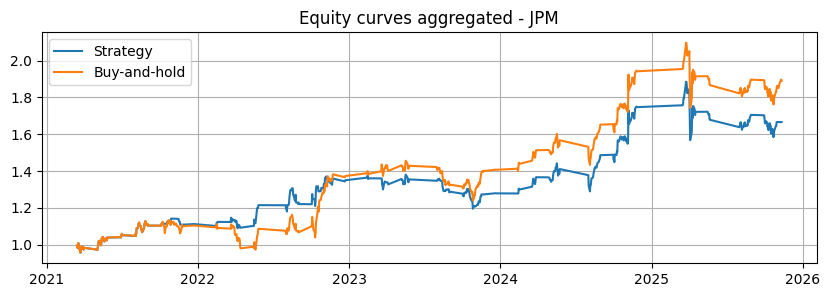

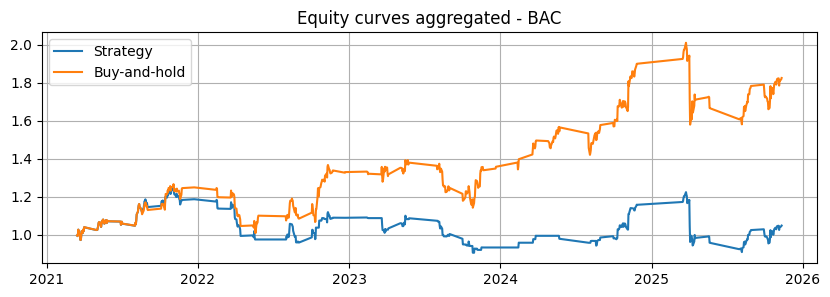

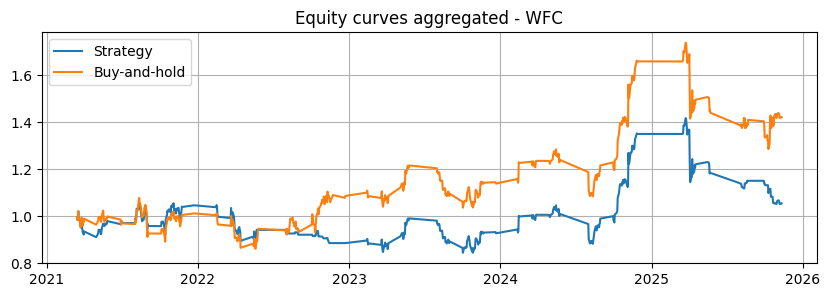

In [12]:
# Cell 11 - Plot equity curves aggregated
for t in tickers:
    try:
        df_all = pd.read_csv(f'agg_backtest_{t}.csv', index_col=0, parse_dates=True)
        plt.figure(figsize=(10,3))
        plt.plot((1+df_all['strategy_ret']).cumprod(), label='Strategy')
        plt.plot((1+df_all[f'{t}_ret']).cumprod(), label='Buy-and-hold')
        plt.title(f'Equity curves aggregated - {t}')
        plt.legend()
        plt.grid(True)
        plt.show()
    except Exception as e:
        print("Could not plot", t, e)


In [13]:
# Cell 12 - Diagnostics notes and recommended next steps
print("""
Diagnostics & recommended next steps:
1) If model still collapses to one class -> try:
   - Increase SMOTE sampling_strategy (e.g., SMOTE(sampling_strategy=0.5))
   - Try class_weight='balanced' for linear kernel
   - Add more discriminative features (volatility regime, GARCH residuals, SPX lead indicators)

2) For publication:
   - Report walk-forward aggregated metrics (Sharpe, hit ratio, F1-macro)
   - Report statistical tests: Diebold-Mariano p-value, significance levels
   - Report robustness: bootstrap p-values, parameter sensitivity
   - Include transaction cost sensitivity analysis

3) If training time too long:
   - reduce n_iter in RandomizedSearchCV
   - reduce step_days (bigger step -> fewer folds) or increase step_days (fewer folds)
   - persist best models with joblib.dump for later analysis

4) To produce figures/tables for paper:
   - Use aggregated summary CSVs: summary_{ticker}_walkforward.csv and agg_backtest_{ticker}.csv

If you want, mình sẽ:
- Run this notebook on your uploaded files and return the summary CSVs + plots,
- Or tune parameters / add more features (GARCH residuals, regime flags) automatically.
""")



Diagnostics & recommended next steps:
1) If model still collapses to one class -> try:
   - Increase SMOTE sampling_strategy (e.g., SMOTE(sampling_strategy=0.5))
   - Try class_weight='balanced' for linear kernel
   - Add more discriminative features (volatility regime, GARCH residuals, SPX lead indicators)

2) For publication:
   - Report walk-forward aggregated metrics (Sharpe, hit ratio, F1-macro)
   - Report statistical tests: Diebold-Mariano p-value, significance levels
   - Report robustness: bootstrap p-values, parameter sensitivity
   - Include transaction cost sensitivity analysis

3) If training time too long:
   - reduce n_iter in RandomizedSearchCV
   - reduce step_days (bigger step -> fewer folds) or increase step_days (fewer folds)
   - persist best models with joblib.dump for later analysis

4) To produce figures/tables for paper:
   - Use aggregated summary CSVs: summary_{ticker}_walkforward.csv and agg_backtest_{ticker}.csv

If you want, mình sẽ:
- Run this notebook o